In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
dataset_path = "/content/drive/MyDrive/FaceMaskDataset"

In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3067 images belonging to 2 classes.
Found 766 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 860s 9s/step - accuracy: 0.8200 - loss: 0.5161 - val_accuracy: 0.9151 - val_loss: 0.2054
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 182ms/step - accuracy: 0.9354 - loss: 0.1807 - val_accuracy: 0.9543 - val_loss: 0.1336
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.9462 - loss: 0.1514 - val_accuracy: 0.9491 - val_loss: 0.1460
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 180ms/step - accuracy: 0.9661 - loss: 0.0985 - val_accuracy: 0.9282 - val_loss: 0.2021
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 181ms/step - accuracy: 0.9775 - loss: 0.0675 - val_accuracy: 0.9347 - val_loss: 0.1829


In [ ]:
import os

save_path = "/content/drive/MyDrive/FaceMaskModel"
os.makedirs(save_path, exist_ok=True)

model.save(save_path + "/mask_detector.h5")

Saving with_mask (99).jpg to with_mask (99).jpg


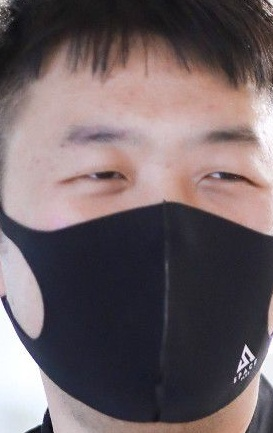

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow
from google.colab import files

model = load_model("/content/drive/MyDrive/FaceMaskModel/mask_detector.h5")

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x,y,w,h) in faces:
        face = img[y:y+h, x:x+w]
        face = cv2.resize(face, (128,128)) / 255.0
        face = np.reshape(face, (1,128,128,3))

        pred = model.predict(face)
        label = "Mask" if pred < 0.5 else "No Mask"
        color = (0,255,0) if label=="Mask" else (0,0,255)

        cv2.rectangle(img,(x,y),(x+w,y+h),color,2)
        cv2.putText(img,label,(x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,color,2)

    cv2_imshow(img)